In [1]:
import sys
sys.path.append("..")
import os
import pandas as pd
from tqdm import tqdm
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "truth_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [3]:
results_dir = f"/hdd/ivny/results/"


def get_leaf_nodes(path):
    leaf_nodes = []
    for root, dirs, files in os.walk(path):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_nodes.append(root)
    return leaf_nodes

leaf_dirs = get_leaf_nodes(results_dir)

direct_qa_leafs = sorted([leaf for leaf in leaf_dirs if "direct_qa_unified_tp" in leaf])   
direct_qa_leafs

['/hdd/ivny/results/mmlu/direct_qa_unified_tp/meta-llama/Llama-3.1-8B-Instruct/2026-04-02_19-07-23',
 '/hdd/ivny/results/mmlu/direct_qa_unified_tp/mistralai/Mistral-7B-Instruct-v0.3/2026-04-02_19-29-02',
 '/hdd/ivny/results/mmlu/direct_qa_unified_tp/openai/gpt-oss-20b/2026-04-02_19-21-34',
 '/hdd/ivny/results/mmlu/direct_qa_unified_tp/qwen/Qwen3-8B/2026-04-02_19-16-45',
 '/hdd/ivny/results/squadv2/direct_qa_unified_tp/meta-llama/Llama-3.1-8B-Instruct/2026-04-02_20-02-09',
 '/hdd/ivny/results/squadv2/direct_qa_unified_tp/mistralai/Mistral-7B-Instruct-v0.3/2026-04-02_20-19-37',
 '/hdd/ivny/results/squadv2/direct_qa_unified_tp/openai/gpt-oss-20b/2026-04-02_20-12-40',
 '/hdd/ivny/results/squadv2/direct_qa_unified_tp/qwen/Qwen3-8B/2026-04-02_20-07-22',
 '/hdd/ivny/results/truthful_qa/direct_qa_unified_tp/meta-llama/Llama-3.1-8B-Instruct/2026-03-31_00-20-25',
 '/hdd/ivny/results/truthful_qa/direct_qa_unified_tp/mistralai/Mistral-7B-Instruct-v0.3/2026-03-31_00-22-38',
 '/hdd/ivny/results/trut

In [4]:
hedged_qa_leafs = sorted([leaf for leaf in leaf_dirs if "hedged_qa_unified_tp" in leaf])
hedged_qa_leafs

['/hdd/ivny/results/mmlu/hedged_qa_unified_tp/meta-llama/Llama-3.1-8B-Instruct/2026-03-30_16-13-24',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_tp/mistralai/Mistral-7B-Instruct-v0.3/2026-03-30_09-24-25',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_tp/openai/gpt-oss-20b/2026-03-30_03-06-35',
 '/hdd/ivny/results/mmlu/hedged_qa_unified_tp/qwen/Qwen3-8B/2026-03-30_07-49-44',
 '/hdd/ivny/results/squadv2/hedged_qa_unified_tp/meta-llama/Llama-3.1-8B-Instruct/2026-03-29_23-54-58',
 '/hdd/ivny/results/squadv2/hedged_qa_unified_tp/mistralai/Mistral-7B-Instruct-v0.3/2026-03-30_02-44-06',
 '/hdd/ivny/results/squadv2/hedged_qa_unified_tp/openai/gpt-oss-20b/2026-03-29_22-44-40',
 '/hdd/ivny/results/squadv2/hedged_qa_unified_tp/qwen/Qwen3-8B/2026-03-30_01-09-33',
 '/hdd/ivny/results/truthful_qa/hedged_qa_unified_tp/meta-llama/Llama-3.1-8B-Instruct/2026-03-29_22-54-19',
 '/hdd/ivny/results/truthful_qa/hedged_qa_unified_tp/mistralai/Mistral-7B-Instruct-v0.3/2026-03-29_23-13-14',
 '/hdd/ivny/results/trut

In [5]:
direct_responses = []
hedged_responses = []

for leaf_dir in direct_qa_leafs:
    direct_responses.extend(pd.read_csv(os.path.join(leaf_dir, "eval_details.csv"))["response_0"].tolist())

for leaf_dir in hedged_qa_leafs:
    hedged_responses.extend(pd.read_csv(os.path.join(leaf_dir, "eval_details.csv"))["response_0"].tolist())

In [6]:
print("Direct QA responses:", direct_responses[100500])
print("Hedged QA responses:", hedged_responses[100500])

Direct QA responses: The name of the process which confirms the primality of a number is called a primality test.
Hedged QA responses: The process which confirms the primality of a number with decimal digits is called a primality test.


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
from scipy.stats import gaussian_kde

# ---- Environment stability (keep yours) ----
os.environ["TORCH_COMPILE_DISABLE"] = "1"
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/tmp/torchinductor_cache"
os.environ["TRITON_CACHE_DIR"] = "/tmp/triton_cache"
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HOME"] = "/tmp/huggingface"
os.environ["HUGGINGFACE_HUB_CACHE"] = "/tmp/huggingface/hub"

from sentence_transformers import CrossEncoder

# ---- Your data ----
list1 = direct_responses   # original (x1)
list2 = hedged_responses  # rewritten (x2)

# # ---- Sample at most 10000 pairs ----
# max_samples = 10000
# if len(list1) > max_samples:
#     rng = np.random.default_rng(42)
#     indices = rng.choice(len(list1), size=max_samples, replace=False)
#     list1 = [list1[i] for i in indices]
#     list2 = [list2[i] for i in indices]

# ---- Load NLI model (DeBERTa) ----
model = CrossEncoder("cross-encoder/nli-deberta-v3-base")

# ---- Direction: rewrite -> original ----
pairs_21 = [(str(x2), str(x1)) for x1, x2 in zip(list1, list2)]


logits_21 = model.predict(
    pairs_21,
    batch_size=128,
    show_progress_bar=True
)

probs_21 = sp.softmax(logits_21, axis=1)

# NLI label order: [contradiction, entailment, neutral]
entail_21 = probs_21[:, 1]
neutral_21 = probs_21[:, 2]

# ---- Soft entailment (lenient) ----
similarities = entail_21 + 0.5 * neutral_21

/mnt/hdd_1/home/ivan/miniconda3/envs/llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 836/836 [04:05<00:00,  3.41it/s]


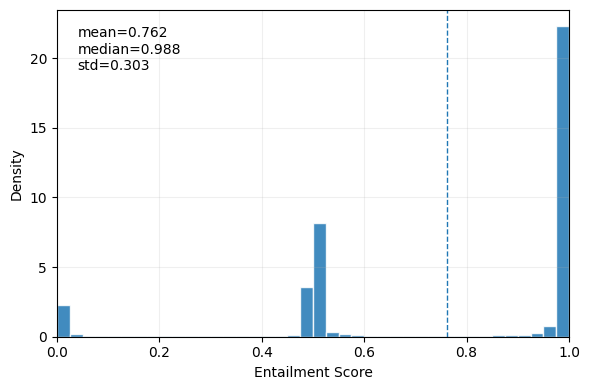

In [8]:
# ---- Plot (same style as yours) ----
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
bins = np.linspace(0.0, 1.0, 41)

ax.hist(similarities, bins=bins, density=True, alpha=0.85, edgecolor="white")
ax.axvline(np.mean(similarities), linestyle="--", linewidth=1)


# ax.set_title("Calibrated Response Entailment (DeBERTa NLI)")
ax.set_xlabel("Entailment Score")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
ax.grid(alpha=0.2)

ax.text(
    0.04,
    0.95,
    f"mean={np.mean(similarities):.3f}\nmedian={np.median(similarities):.3f}\nstd={np.std(similarities):.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
)

plt.tight_layout()
plt.savefig("hedged_direct_qa_response_entailment_scores.pdf", dpi=300, bbox_inches="tight")
plt.show()